In [1]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [4]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/')
from ESMCBA.imports import *
from ESMCBA import other_utils

In [3]:
evaluations_dt = pd.read_csv('../models_performances_22032025.csv')
evaluations_dt = evaluations_dt.sort_values(by=['spearman','mse'], ascending = [False, True]).reset_index(drop=True)

In [196]:
evaluations_dt2 = other_utils.get_all_evaluations('/global/scratch/users/sergiomar10/losses/ESMCBA_22042025/*.csv')
evaluations_dt = evaluations_dt[(evaluations_dt['time'].str.contains('2025-04-1')) ] 

In [197]:
evaluations_dt2[evaluations_dt2['HLA'] == 'A1101']

,HLA,Losses,encoding,data_prop,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,mse,mae,r2,rmse,time,path
41,A1101,Hubber,epitope,0.95,30,0.0001,0.0001,110,0.652995,0.647814,1.173090,0.853677,0.381586,1.083093,2025-04-22 14:54:38,/global/scratch/users/sergiomar10/losses/ESMCB...
117,A1101,Hubber,epitope,0.85,30,0.0001,0.0001,110,0.694385,0.663337,1.102247,0.832513,0.418932,1.049880,2025-04-22 14:47:45,/global/scratch/users/sergiomar10/losses/ESMCB...
125,A1101,Hubber,epitope,0.8,30,0.0001,0.0001,110,0.650611,0.667424,1.057366,0.807318,0.442592,1.028283,2025-04-22 14:28:58,/global/scratch/users/sergiomar10/losses/ESMCB...
164,A1101,Hubber,HLA,0.95,30,0.0001,0.0001,110,0.748836,0.731864,1.037921,0.857241,0.452842,1.018784,2025-04-22 14:50:07,/global/scratch/users/sergiomar10/losses/ESMCB...


In [198]:
evaluations_dt = pd.concat([evaluations_dt, evaluations_dt2], axis=0)
evaluations_dt = evaluations_dt.reset_index(drop=True)

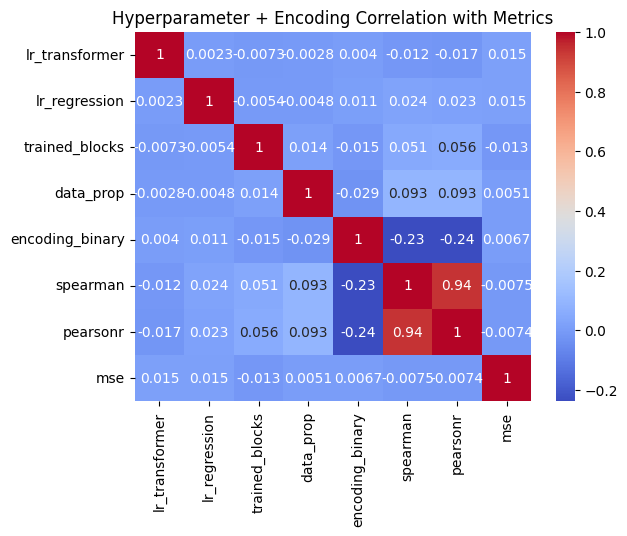

Encoding vs Spearman correlation: nan (p = nan)


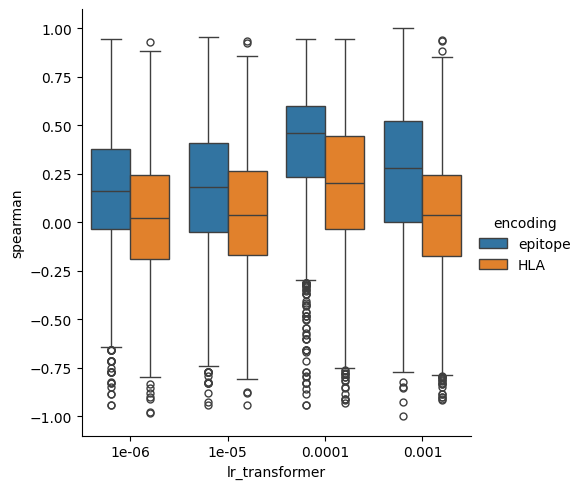

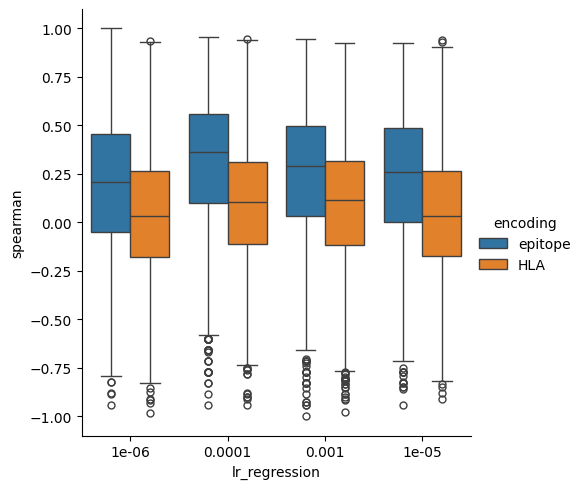

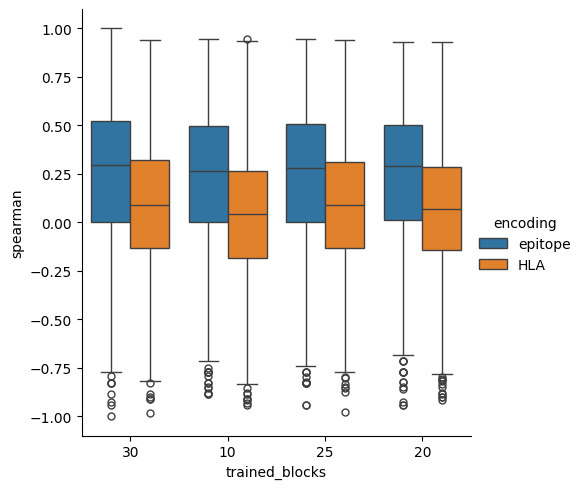

In [199]:
# Copy the DataFrame
df_corr = evaluations_dt.copy()

# Convert 'encoding' to binary (e.g., epitope=0, HLA=1)
df_corr['Losses_binary'] = df_corr['Losses'].map({'MSE': 0, 'Hubber': 1})

# Convert 'encoding' to binary (e.g., epitope=0, HLA=1)
df_corr['encoding_binary'] = df_corr['encoding'].map({'epitope': 0, 'HLA': 1})

# Select numeric columns
numeric_hyperparams = df_corr[[
    'lr_transformer', 'lr_regression', 'trained_blocks', 'data_prop', 'encoding_binary',  'spearman', 'pearsonr', 'mse'
]].astype(float)

# Compute correlation matrix
correlation_matrix = numeric_hyperparams.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Hyperparameter + Encoding Correlation with Metrics")
plt.show()


from scipy.stats import pointbiserialr
# Point-biserial correlation
r, p = pointbiserialr(df_corr['encoding_binary'], df_corr['spearman'])
print(f"Encoding vs Spearman correlation: {r:.3f} (p = {p:.3g})")

evaluations_dt['lr_transformer'] = evaluations_dt['lr_transformer'].astype(float)

# sns.catplot(data=evaluations_dt, x='lr_transformer', y='spearman', hue='Losses', kind='box')
sns.catplot(data=evaluations_dt, x='lr_transformer', y='spearman', hue='encoding', kind='box')

# sns.catplot(data=evaluations_dt, x='lr_regression', y='spearman', hue='Losses', kind='box')
sns.catplot(data=evaluations_dt, x='lr_regression', y='spearman', hue='encoding', kind='box')

# sns.catplot(data=evaluations_dt, x='trained_blocks', y='spearman', hue='Losses', kind='box')
sns.catplot(data=evaluations_dt, x='trained_blocks', y='spearman', hue='encoding', kind='box')

In [200]:
evaluations_dt[(evaluations_dt['HLA'] == ('A1101'))]['encoding'].unique()

array(['HLA', 'epitope'], dtype=object)

In [201]:
evaluations_dt_sorted =  evaluations_dt.sort_values(by='mse', ascending = True)
evaluations_dt_sorted['Model'] = evaluations_dt_sorted['HLA'] + ' ' + evaluations_dt_sorted['encoding']
evaluations_dt_sorted = evaluations_dt_sorted.drop_duplicates('Model')
# evaluations_dt_sorted #.sort_values(by='spearman', ascending = False)

In [202]:
evaluations_dt_sorted[(evaluations_dt_sorted['HLA'] == ('A1101'))]

,HLA,Losses,encoding,data_prop,trained_blocks,lr_transformer,lr_regression,n_evaluations,spearman,pearsonr,mse,mae,r2,rmse,time,path,Model
187,A1101,Hubber,HLA,0.5,30,0.0001,0.0001,110,0.797718,0.783970,0.736651,0.654020,0.611662,0.858284,2025-04-18 06:36:05,/global/scratch/users/sergiomar10/losses/ESMCB...,A1101 HLA
12902,A1101,Hubber,epitope,0.8,30,0.0001,0.0001,110,0.650611,0.667424,1.057366,0.807318,0.442592,1.028283,2025-04-22 14:28:58,/global/scratch/users/sergiomar10/losses/ESMCB...,A1101 epitope


In [221]:
results = []
test_datasets_list = []

# Get unique HLA alleles
alleles = evaluations_dt_sorted['Model'].unique()

for allele in alleles:
    # Load training data for the current allele
    formatted_HLA = allele.split(' ')[0]# .replace('*', '').replace(':', '').
    train_fasta = f"/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA{formatted_HLA}_final.csv"
    epitope_data = pd.read_csv(train_fasta, header=None)
    epitope_data.columns = ['sequence', 'ref_ID', 'submissionID', 'Epitope_ID', 'protein_origin', 
                            'ID_SOURCE', 'SOURCE_ORGANISM', 'IC50_nM', 'DESCRIPTION_BINDING', 'Year_submission']
    
    # Clean and filter the training data
    epitope_data['Year_submission'] = epitope_data['Year_submission'].astype(str).replace('\\N', '0').astype(int)
    epitope_data = epitope_data[epitope_data["Year_submission"] < 2019]

    # Load test data for the current allele
    test_path = evaluations_dt_sorted[evaluations_dt_sorted['Model'] == allele]['path'].values[0]
    test_dataset = pd.read_csv(test_path)
    
    # Remove training sequences from the test data
    test_dataset = test_dataset[~test_dataset['sequence'].isin(epitope_data['sequence'])]
    
    # If the filtered test dataset is empty, skip this allele
    if test_dataset.empty:
        continue

    # Store the test dataset with an added column for HLA
    test_dataset = test_dataset.copy()  # Ensure we're not modifying the original DataFrame unexpectedly
    test_dataset['HLA'] = allele
    test_datasets_list.append(test_dataset)
    
    # Only compute metrics if there is more than one sample
    if len(test_dataset) > 1:
        spearman_val = spearmanr(test_dataset['measured'], test_dataset['prediction'])[0]
        pearson_val = pearsonr(test_dataset['measured'], test_dataset['prediction'])[0]
        mse_val = mean_squared_error(test_dataset['measured'], test_dataset['prediction'])
        
        # Format to 2 significant figures
        spearman_str = f"{spearman_val:.2g}"
        pearson_str = f"{pearson_val:.2g}"
        mse_str = f"{mse_val:.2g}"
        
        results.append({
            "HLA": formatted_HLA,
            "spearman": spearman_str,
            "pearsonr": pearson_str,
            "mse": mse_str,
            "test_size": len(test_dataset),
            "path": test_path,
            "training_data": len(epitope_data),
            "encoding": evaluations_dt_sorted[evaluations_dt_sorted['Model'] == allele]['encoding'].values[0],
            "Model": allele,
        })
else:
    print(f"All test datasets were empty for HLA {allele}. Skipping this allele.")

# Create a DataFrame with the metrics results
metrics_df = pd.DataFrame(results)

# Concatenate all test datasets into a single DataFrame
if test_datasets_list:
    test_datasets_df = pd.concat(test_datasets_list, ignore_index=True)
else:
    test_datasets_df = pd.DataFrame()  # empty DataFrame if no test datasets were stored

# Now you have:
# - metrics_df: contains the computed metrics for each HLA allele.
# - test_datasets_df: contains all the filtered test datasets with an HLA identifier.

All test datasets were empty for HLA B4402 epitope. Skipping this allele.


In [233]:
pd.merge(left=metrics_df, right=evaluations_dt_sorted[['HLA','time','Model']], on='Model', how='left').reset_index(drop=True).sort_values(by=['HLA_x','Model'], ascending=True).head(30)

,HLA_x,spearman,pearsonr,mse,test_size,path,training_data,encoding,Model,HLA_y,time
64,A0101,0.62,0.68,2.6,128,/global/scratch/users/sergiomar10/losses/ESMCB...,3790,HLA,A0101 HLA,A0101,2025-04-22 15:12:10
60,A0101,0.54,0.57,1.9,128,/global/scratch/users/sergiomar10/losses/ESMCB...,3790,epitope,A0101 epitope,A0101,2025-04-19 15:28:37
57,A0201,0.57,0.56,1.6,495,/global/scratch/users/sergiomar10/losses/ESMCB...,16550,epitope,A0201 epitope,A0201,2025-04-19 13:43:10
11,A0202,0.87,0.86,0.29,375,/global/scratch/users/sergiomar10/losses/ESMCB...,5287,epitope,A0202 epitope,A0202,2025-04-22 14:40:10
35,A0211,0.72,0.66,0.79,17,/global/scratch/users/sergiomar10/losses/ESMCB...,715,epitope,A0211 epitope,A0211,2025-04-19 15:51:21
20,A0216,-0.24,-0.28,0.47,8,/global/scratch/users/sergiomar10/losses/ESMCB...,604,HLA,A0216 HLA,A0216,2025-04-18 10:32:25
45,A0219,0.65,0.68,1.2,18,/global/scratch/users/sergiomar10/losses/ESMCB...,836,epitope,A0219 epitope,A0219,2025-04-22 14:32:40
54,A0301,0.58,0.56,1.5,223,/global/scratch/users/sergiomar10/losses/ESMCB...,6278,HLA,A0301 HLA,A0301,2025-04-17 19:29:03
61,A0301,0.58,0.54,2.1,223,/global/scratch/users/sergiomar10/losses/ESMCB...,6278,epitope,A0301 epitope,A0301,2025-04-22 14:26:30
31,A1101,0.8,0.78,0.74,110,/global/scratch/users/sergiomar10/losses/ESMCB...,5717,HLA,A1101 HLA,A1101,2025-04-18 06:36:05


In [189]:
hla_sequences = []

# Process each HLA and its evaluation file
for hla, eval_path in evaluations_dt_sorted[['HLA', 'path']].values:

    # # Load evaluation data
    dt = pd.read_csv(eval_path)
    sequences = dt['sequence'].unique()
    hla_formatted = f"HLA-{hla}"  # e.g., 'HLA-A1101'

    # Collect HLA and sequence pairs
    for seq in sequences:
        hla_sequences.append([hla_formatted, seq])


In [8]:
# Load Data S2: Monoallelic benchmark dataset with predictions
test_data = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/Data_S2.csv')

In [9]:
test_data['hla'] = test_data['hla'].str.replace('-', '').str.replace('*', '').str.replace(':', '')  # Remove 'HLA-' prefix

In [10]:
evaluations_dt_sorted = evaluations_dt[evaluations_dt['encoding'] == 'epitope'].sort_values(by='mse', ascending = True) #.drop_duplicates('HLA') #[evaluations_dt['Losses'] == 'MSE']
evaluations_dt_sorted = evaluations_dt_sorted[evaluations_dt_sorted['HLA'].apply(len) == 8] 
# evaluations_dt_sorted #.sort_values(by='spearman', ascending = False)

In [13]:
IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/data/IEDB_full_subset_filtered_out_MHCFlurry.csv', sep = ',', header = 0)
IEDB_full.head()

,Assay - Qualitative Measurement,peptide,MHC Restriction - Name
0,Positive-High,LITGRLQSL,HLA-A2
1,Positive,LIYDSSLCDL,HLA-A2
2,Positive,GLLGTLVQ,HLA-A2
3,Positive,NLTISDVSV,HLA-A2
4,Positive,LPAVVGLSPGEQEY,HLA-B*35:01


In [14]:
IEDB_full['HLA'] = IEDB_full['MHC Restriction - Name'].str.replace('-', '').str.replace('*', '').str.replace(':', '')  # Remove 'HLA-' prefix

In [3]:
import pandas as pd

In [7]:
evaluations_dt_sorted = pd.read_csv('../../performances/models_performances_23042025.csv')
evaluations_dt_sorted = evaluations_dt_sorted[evaluations_dt_sorted['HLA'] == 'A0201']

In [52]:
rfd_peptides = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/HLAA0201_PDB_7RTD_RFdiffusion_sequences.csv')
rfd_peptides = rfd_peptides[(rfd_peptides['plddt'] > 0.8)]
print(len(rfd_peptides))


602


In [54]:
rfd_peptides = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/jupyter_notebooks/rdfiffusion/HLAA0201_PDB_7RTD_RFdiffusion_sequences.csv')
rfd_peptides = rfd_peptides[(rfd_peptides['plddt'] < 0.2)]
print(len(rfd_peptides))


71


In [55]:
import os
import re

name = 'lowbinders'
# Set up directories
sh_file_dir       = '/global/scratch/users/sergiomar10/slurm_jobs/RFDBENCH'
output_dir        = '/global/scratch/users/sergiomar10/benchmark/RFD_BENCHMARK'
mhcflurry_out_dir = os.path.join(output_dir, 'mhcflurry')
logs_dir          = '/global/scratch/users/sergiomar10/logs/RFD_BENCHMARK'

for d in (sh_file_dir, output_dir, mhcflurry_out_dir, logs_dir):
    os.makedirs(d, exist_ok=True)

for hla in evaluations_dt_sorted['Model'].unique():
    rows = evaluations_dt_sorted[
        evaluations_dt_sorted['Model'] == hla
    ][['HLA','path']].values

    for allele, eval_path in rows:
        # clean names
        allele_clean = allele.split()[0].replace('*','').replace(':','').replace(' ','')
        hla_clean    = allele_clean.replace('HLA','')
        model_fn     = os.path.basename(eval_path).replace('evaluation_','').replace('.csv','_final.pth')
        model_path   = f'/global/scratch/users/sergiomar10/models/ESMCBA_21032025/{hla_clean}/{model_fn}'

        if not os.path.exists(model_path):
            print(f"❌ Model missing: {model_path}")
            continue
        print(f"✅ Using model: {model_path}")

        # collect peptides
        peptides = (
            rfd_peptides['epitope']
            .unique().tolist()
        )
        cleaned = [
            pep for pep in peptides
            if 8 <= len(pep) <= 11 and not re.search(r'[<\(\)\*\s\+]', pep)
        ]
        if not cleaned:
            print(f"⚠️ No peptides for {allele}")
            continue

        # write .pep FASTA
        pepe       = allele_clean.replace('HLA','HLA-')
        fasta_file = os.path.join(output_dir, f"{pepe}.pep")
        with open(fasta_file,'w') as f:
            for i, pep in enumerate(cleaned,1):
                f.write(f">pep{i}\n{pep}\n")

        hla = hla.replace(' ','')

        # build commands
        esmcba_cmd = (
            f"conda activate /clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian \n"
            f"python3 /global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/model_evaluation.py "
            f"--model_path {model_path} "
            f"--hla {hla}-{name} "
            f"--output_dir {output_dir} "
            f"--peptides {' '.join(cleaned)}"
        )
        mhcflurry_cmd = (
            f"conda activate /clusterfs/nilah/sergio/miniconda3/envs/cooltools \n"
            f"mhcflurry-predict --alleles {allele_clean} "
            f"--peptides {' '.join(cleaned)} "
            f"--out {os.path.join(mhcflurry_out_dir, allele_clean+name+'_mhc_flurry.csv')}"
        )
        netmhc_cmd = (
            f"cd {output_dir} && "
            f"/global/scratch/users/sergiomar10/tools/netMHCpan-4.1/netMHCpan "
            f"-a HLA-{allele_clean} -f {pepe}.pep -BA -xls -xlsfile {name}_{allele_clean}_netmhc.xls"
        )

        # package them up
        for tag, cmd in (('esmcba', esmcba_cmd),
                         ('mhcflurry', mhcflurry_cmd),
                         ('netmhcpan', netmhc_cmd)):

            if tag == 'esmcba':
                run_id = f"{allele_clean}_{tag}_{model_fn}"
                sh_path= os.path.join(sh_file_dir, f"{name}_{run_id}.sh")
            else:
                run_id = f"{allele_clean}_{tag}"
                sh_path= os.path.join(sh_file_dir, f"{name}_{run_id}.sh")
            with open(sh_path,'w') as sb:
                sb.write("#!/bin/bash\n")
                sb.write("#SBATCH --account=co_nilah\n")
                sb.write("#SBATCH --partition=savio3_gpu\n")
                sb.write("#SBATCH --cpus-per-task=4\n")
                sb.write("#SBATCH --gres=gpu:1\n")
                sb.write("#SBATCH --time=00:40:00\n")
                sb.write(f"#SBATCH --job-name={run_id}\n")
                sb.write(f"#SBATCH --output={logs_dir}/{run_id}_%j.out\n")
                sb.write(f"#SBATCH --error={logs_dir}/{run_id}_%j.err\n\n")
                sb.write("source /clusterfs/nilah/sergio/miniconda3/etc/profile.d/conda.sh\n")
                # sb.write("")
                sb.write(cmd + "\n")

            os.chmod(sh_path, 0o755)
            print(f"✅ Wrote {tag} script: {sh_path}")


✅ Using model: /global/scratch/users/sergiomar10/models/ESMCBA_21032025/A0201/ESMCBA_HLA_0.95_30_ESMMASK_HLA_FT_20_0.0001_5e-05_AUG_1_A0201_1_0.0001_0.0001__1_A0201_0404_Hubber_A0201_final.pth
✅ Wrote esmcba script: /global/scratch/users/sergiomar10/slurm_jobs/RFDBENCH/lowbinders_A0201_esmcba_ESMCBA_HLA_0.95_30_ESMMASK_HLA_FT_20_0.0001_5e-05_AUG_1_A0201_1_0.0001_0.0001__1_A0201_0404_Hubber_A0201_final.pth.sh
✅ Wrote mhcflurry script: /global/scratch/users/sergiomar10/slurm_jobs/RFDBENCH/lowbinders_A0201_mhcflurry.sh
✅ Wrote netmhcpan script: /global/scratch/users/sergiomar10/slurm_jobs/RFDBENCH/lowbinders_A0201_netmhcpan.sh
✅ Using model: /global/scratch/users/sergiomar10/models/ESMCBA_21032025/A0201/ESMCBA_epitope_0.95_30_ESMMASK_epitope_FT_15_0.001_1e-05_AUG_3_A0201_2_0.0001_0.0001__1_A0201_0404_Hubber_A0201_final.pth
✅ Wrote esmcba script: /global/scratch/users/sergiomar10/slurm_jobs/RFDBENCH/lowbinders_A0201_esmcba_ESMCBA_epitope_0.95_30_ESMMASK_epitope_FT_15_0.001_1e-05_AUG_3_A020

In [28]:
model_fn

'ESMCBA_epitope_0.95_30_ESMMASK_epitope_FT_15_0.001_1e-05_AUG_3_A0201_2_0.0001_0.0001__1_A0201_0404_Hubber_A0201_final.pth'

In [20]:
len(cleaned)

15138

In [26]:

    # Save to .pep FASTA file
    pepe = allele_clean.replace('HLA', 'HLA-')
    fasta_filename = os.path.join(output_dir, f"{pepe}.pep")
    with open(fasta_filename, "w") as fout:
        for i, pep in enumerate(cleaned_peptides, 1):
            fout.write(f">pep{i}\n{pep}\n")

    print(f"📁 Saved {len(cleaned_peptides)} peptides for {allele} to {fasta_filename}")

    # Build mhcflurry and netMHCpan commands
    mhcflurry_outfile = os.path.join(mhcflurry_out_dir, f"{allele_clean}_mhc_flurry.csv")
    mhcflurry_cmd = (
        f"mhcflurry-predict --alleles {allele_clean} "
        f"--peptides {' '.join(cleaned_peptides)} "
        f"--out {mhcflurry_outfile}"
    )

    netmhc_cmd = (
        f"cd {output_dir} && "
        f"/global/scratch/users/sergiomar10/ESMCBA/tools/netMHCpan-4.1/netMHCpan "
        f"-a {allele_clean} -f {allele_clean}.pep -BA -xls -xlsfile {allele_clean}_netmhc.xls"
    )

'/global/scratch/users/sergiomar10/ESCMBA/models/weights/ESMCBA_epitope_0.8_30_ESMMASK_epitope_FT_25_0.0001_1e-06_AUG_3_HLAA2402_2_0.001_0.001__2_A2402_Hubber_A2402_final.pth'

In [ ]:
eval_model_df = pd.DataFrame(evaluated_models_log)

In [ ]:
eval_model_df['model_path'] = eval_model_df['model_path'].str.replace('/global/scratch/users/sergiomar10/models/','')

In [ ]:
import shutil

destination_dir = '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA'
os.makedirs(destination_dir, exist_ok=True)

for row in evaluated_models_log:
    src = row['model_path']
    filename = os.path.basename(src)
    dest = os.path.join(destination_dir, filename)

    try:
        shutil.copy2(src, dest)  # copy2 preserves metadata
        print(f"✅ Copied {filename} to {destination_dir}")
    except Exception as e:
        print(f"❌ Failed to copy {src} → {dest}: {e}")


✅ Copied ESMCBA_epitope_0.5_20_ESMMASK_epitope_FT_25_0.0001_1e-06_AUG_1_HLAA0206_2_0.001_1e-06__1_A0206_Hubber_A0206_final.pth to /global/scratch/users/sergiomar10/ESMCBA/ESMCBA
✅ Copied ESMCBA_epitope_0.95_30_ESMMASK_epitope_FT_25_0.001_0.001_AUG_6_HLAA0203_2_0.001_0.001__2_A0203_Hubber_A0203_final.pth to /global/scratch/users/sergiomar10/ESMCBA/ESMCBA
✅ Copied ESMCBA_epitope_0.5_20_ESMMASK_epitope_FT_25_0.001_1e-06_AUG_3_HLAB3701_1_0.0001_1e-05__1_B3701_0404_Hubber_B3701_final.pth to /global/scratch/users/sergiomar10/ESMCBA/ESMCBA
✅ Copied ESMCBA_epitope_0.95_20_ESMMASK_epitope_FT_20_0.001_1e-06_AUG_1_HLAA2501_1_0.0001_1e-06__1_A2501_0404_Hubber_A2501_final.pth to /global/scratch/users/sergiomar10/ESMCBA/ESMCBA
✅ Copied ESMCBA_epitope_0.95_30_ESMMASK_epitope_FT_20_0.001_0.001_AUG_1_HLAA3301_5_0.001_1e-06__4_A3301_Hubber_A3301_final.pth to /global/scratch/users/sergiomar10/ESMCBA/ESMCBA
✅ Copied ESMCBA_epitope_0.95_30_ESMMASK_epitope_FT_25_0.001_1e-05_AUG_6_HLAA6802_2_0.001_1e-06__4_A

In [ ]:
# Load Data S3: Training data for MHCflurry 2.0 BA predictor
training_data = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/Data_S3.csv')
print(f"Training data shape: {training_data.shape}")

Training data shape: (713069, 12)


In [ ]:
training_data['allele'] = training_data['allele'].str.replace('-', '').str.replace('*', '').str.replace(':', '')  # Remove 'HLA-' prefix

In [ ]:
testing_set_filtered = pd.DataFrame()

for HLA in test_datasets_df['HLA'].unique():
    training_data_subset = training_data[training_data['allele'] == HLA]

    test_datasets_df_subset = test_datasets_df[test_datasets_df['HLA'] == HLA]
    test_datasets_df_subset = test_datasets_df_subset[~test_datasets_df_subset['sequence'].isin(training_data_subset['peptide'])]

    testing_set_filtered = pd.concat([testing_set_filtered, test_datasets_df_subset], ignore_index=True)

In [1]:
import os
import pandas as pd

# Load your test data
# testing_set_filtered = pd.read_csv("path/to/testing_set_filtered.csv")

# Output dirs
sh_file_dir = '/global/scratch/users/sergiomar10/slurm_jobs/MHCF_ESMCBA'
output_dir = '/global/scratch/users/sergiomar10/benchmark/MSE_loss/NETMHCSPAN4'
mhcflurry_out_dir = '/global/scratch/users/sergiomar10/benchmark/MSE_loss/MHCFlurry'
os.makedirs(sh_file_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)
os.makedirs(mhcflurry_out_dir, exist_ok=True)

aa = set("ACDEFGHIKLMNPQRSTVWY")  # valid amino acids

# Loop through each HLA in testing set
unique_hlas = testing_set_filtered['HLA'].unique()
print(f"📊 Found {len(unique_hlas)} unique HLAs in testing set.")

for allele in unique_hlas:
    allele_peptides = testing_set_filtered[testing_set_filtered['HLA'] == allele]['sequence'].unique()
    allele_clean = allele.replace('HLA-', '').replace('*', '').replace(':', '').replace(' ', '')

    # Clean peptides
    cleaned_peptides = [
        ''.join([aa_ for aa_ in p if aa_.upper() in aa])
        for p in allele_peptides if isinstance(p, str)
    ]
    cleaned_peptides = [p for p in cleaned_peptides if p]

    if len(cleaned_peptides) == 0:
        print(f"⚠️ No valid peptides found for {allele}. Skipping.")
        continue

    run_id = f"EVAL_MHCFLURRY_TEST_{allele_clean}"

    # Save to .pep FASTA file
    pepe = allele_clean.replace('HLA', 'HLA-')
    fasta_filename = os.path.join(output_dir, f"{pepe}.pep")
    with open(fasta_filename, "w") as fout:
        for i, pep in enumerate(cleaned_peptides, 1):
            fout.write(f">pep{i}\n{pep}\n")

    print(f"📁 Saved {len(cleaned_peptides)} peptides for {allele} to {fasta_filename}")

    # Build mhcflurry and netMHCpan commands
    mhcflurry_outfile = os.path.join(mhcflurry_out_dir, f"{allele_clean}_mhc_flurry.csv")
    mhcflurry_cmd = (
        f"mhcflurry-predict --alleles {allele_clean} "
        f"--peptides {' '.join(cleaned_peptides)} "
        f"--out {mhcflurry_outfile}"
    )

    netmhc_cmd = (
        f"cd {output_dir} && "
        f"/global/scratch/users/sergiomar10/ESMCBA/tools/netMHCpan-4.1/netMHCpan "
        f"-a {allele_clean} -f {allele_clean}.pep -BA -xls -xlsfile {allele_clean}_netmhc.xls"
    )

    # Write SLURM script
    sh_filepath = os.path.join(sh_file_dir, f"{run_id}.sh")
    try:
        with open(sh_filepath, 'w') as sh_file:
            sh_file.write('#!/bin/bash\n')
            sh_file.write('#SBATCH --account=co_nilah\n')
            sh_file.write('#SBATCH --partition=savio2_1080ti\n')
            sh_file.write('#SBATCH --qos=savio_lowprio\n')
            sh_file.write('#SBATCH --cpus-per-task=4\n')
            sh_file.write('#SBATCH --gres=gpu:1\n')
            sh_file.write('#SBATCH --time=00:40:00\n')
            sh_file.write(f'#SBATCH --job-name={run_id}\n')
            sh_file.write(f'#SBATCH --output=/global/scratch/users/sergiomar10/logs/MHCFlurry_evals/{run_id}_%j.out\n')
            sh_file.write(f'#SBATCH --error=/global/scratch/users/sergiomar10/logs/MHCFlurry_evals/{run_id}_%j.err\n\n')
            sh_file.write('source /clusterfs/nilah/sergio/miniconda3/etc/profile.d/conda.sh\n')
            sh_file.write('conda activate /clusterfs/nilah/sergio/miniconda3/envs/cooltools\n\n')
            sh_file.write(f"{mhcflurry_cmd}\n")
            sh_file.write(f"{netmhc_cmd}\n")

        os.chmod(sh_filepath, 0o755)
        print(f"✅ Created SLURM script: {sh_filepath}")
    except Exception as e:
        print(f"❌ Error writing script for {allele}: {e}")


NameError: name 'testing_set_filtered' is not defined

In [ ]:
allele_clean.replace('HLA', 'HLA-')

'HLA-A2402'